In [12]:
%load_ext autoreload
%autoreload 2

from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cdk.logging

log = cdk.logging.setup_logging()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[11/01/24 14:55:32] INFO     Logging initialized                  __init__.py:22


In [13]:
prdata = pr.load_platereader_data("../../tests/test_data/cytation_dna_sweep.txt", "../../tests/test_data/platemap.csv")
data, platemap = prdata
data.head()

,Well,Row,Column,Time,Seconds,Temperature (C),Read,Data,Experiment,Name,DNA Template,[DNA Template] (ng/uL)
0,B1,B,1,0 days 00:00:00,0.0,37.0,"490,520",289.0,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.0
1,B1,B,1,0 days 00:05:00,300.0,37.0,"490,520",312.0,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.0
2,B1,B,1,0 days 00:10:00,600.0,37.0,"490,520",449.0,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.0
3,B1,B,1,0 days 00:15:00,900.0,37.0,"490,520",982.0,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.0
4,B1,B,1,0 days 00:20:00,1200.0,37.0,"490,520",1880.0,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.0


In [14]:
pr.plot_setup()

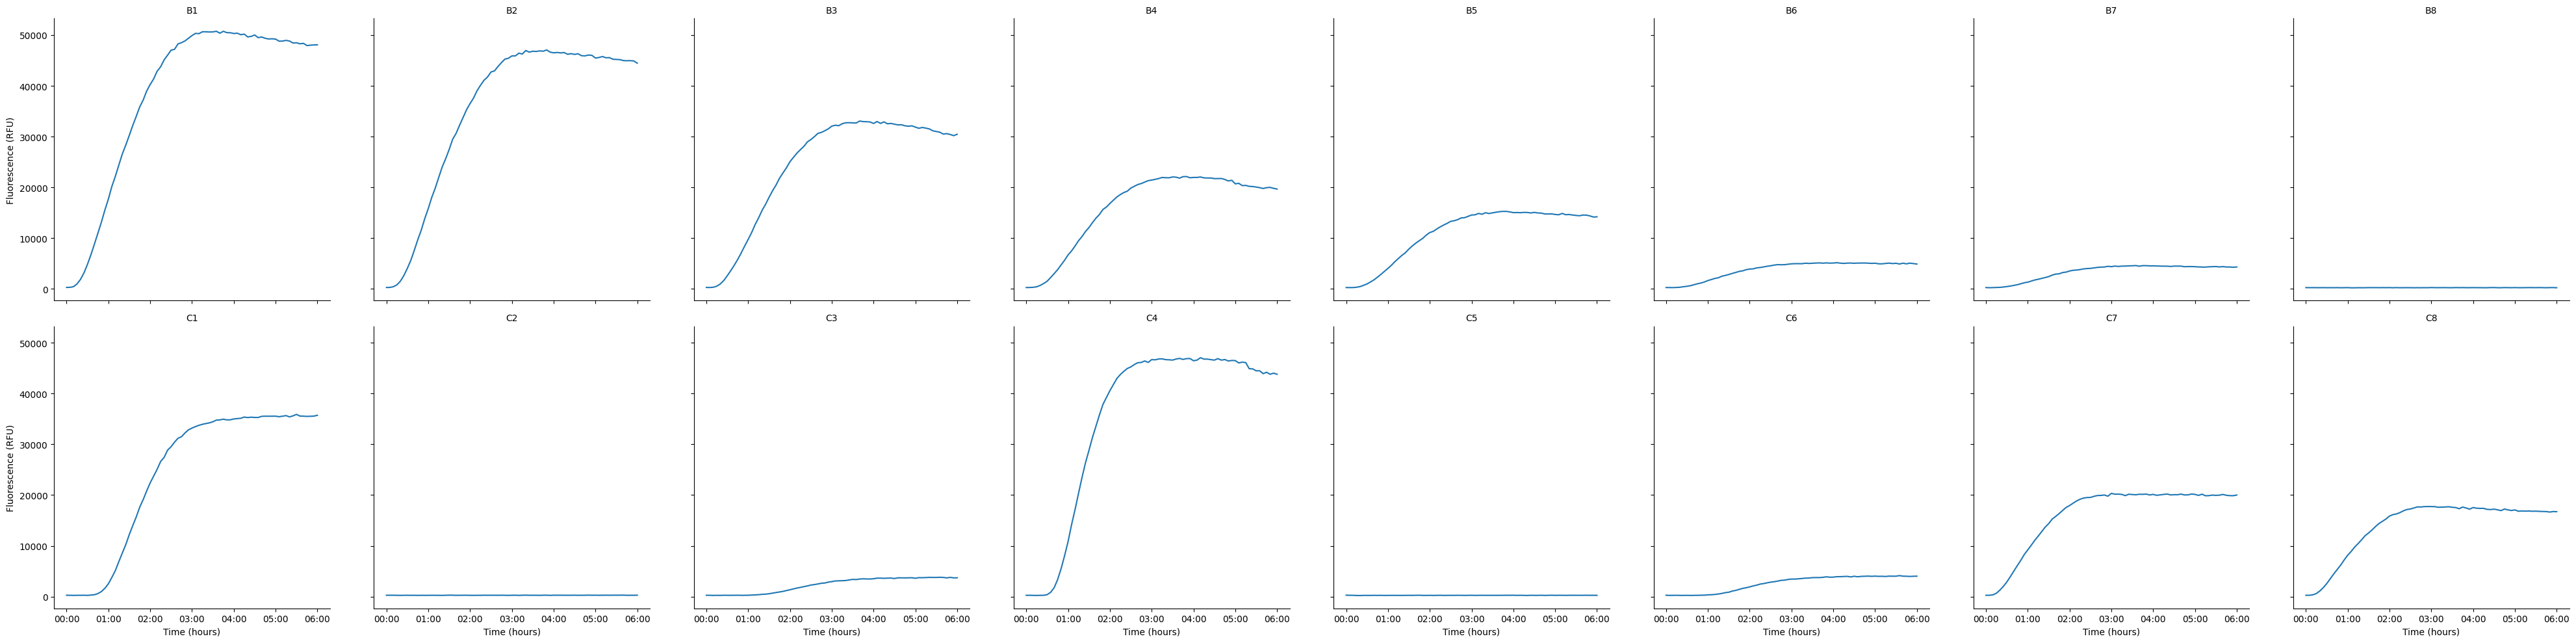

In [15]:
pr.plot_plate(data)

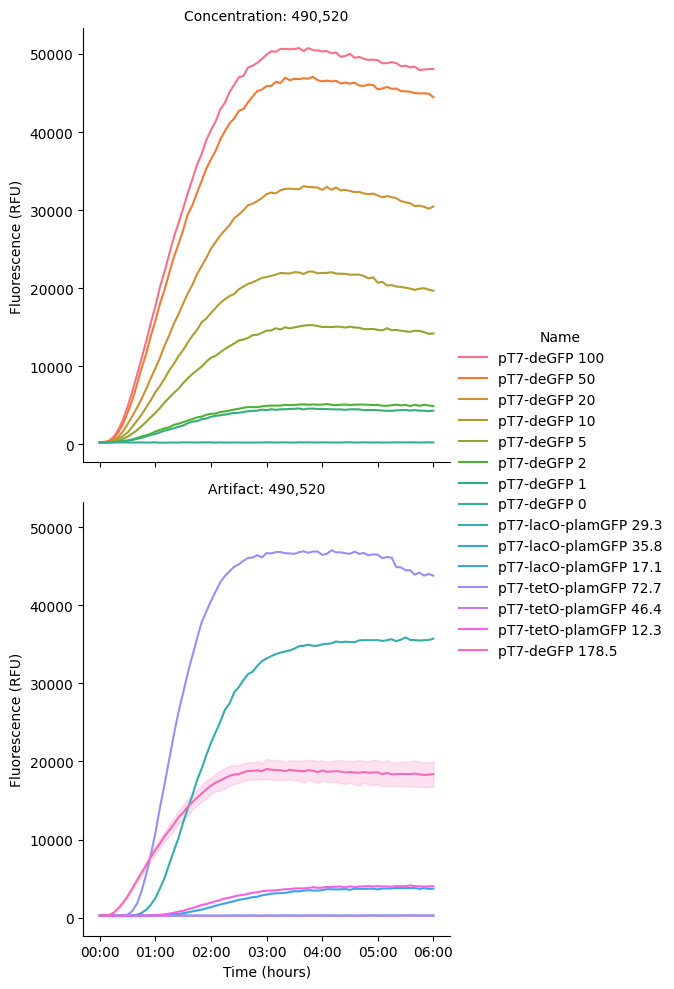

In [17]:
pr.plot_curves_by_name(data=data)


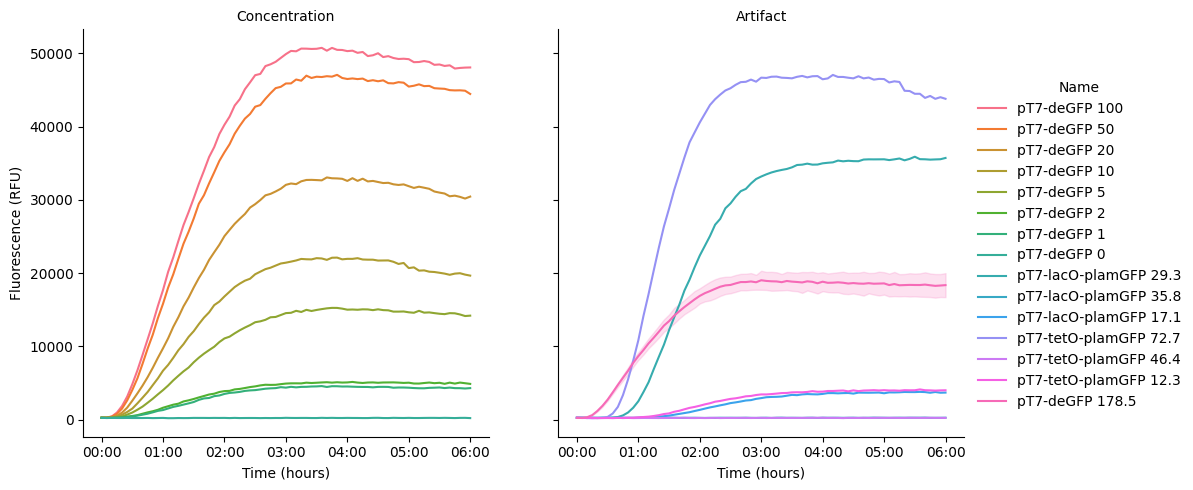

In [18]:
pr.plot_curves(data, hue="Name", col="Experiment")

In [19]:
platemap

,Well,Experiment,Name,DNA Template,[DNA Template] (ng/uL)
0,B1,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.0
1,B2,Concentration,pT7-deGFP 50,pT7-deGFP (AR-11),50.0
2,B3,Concentration,pT7-deGFP 20,pT7-deGFP (AR-11),20.0
3,B4,Concentration,pT7-deGFP 10,pT7-deGFP (AR-11),10.0
4,B5,Concentration,pT7-deGFP 5,pT7-deGFP (AR-11),5.0
5,B6,Concentration,pT7-deGFP 2,pT7-deGFP (AR-11),2.0
6,B7,Concentration,pT7-deGFP 1,pT7-deGFP (AR-11),1.0
7,B8,Concentration,pT7-deGFP 0,pT7-deGFP (AR-11),0.0
8,C1,Artifact,pT7-lacO-plamGFP 29.3,pT7-lacO-plamGFP (20240622),29.3
9,C2,Artifact,pT7-lacO-plamGFP 35.8,pT7-lacO-plamGFP (20240626),35.8


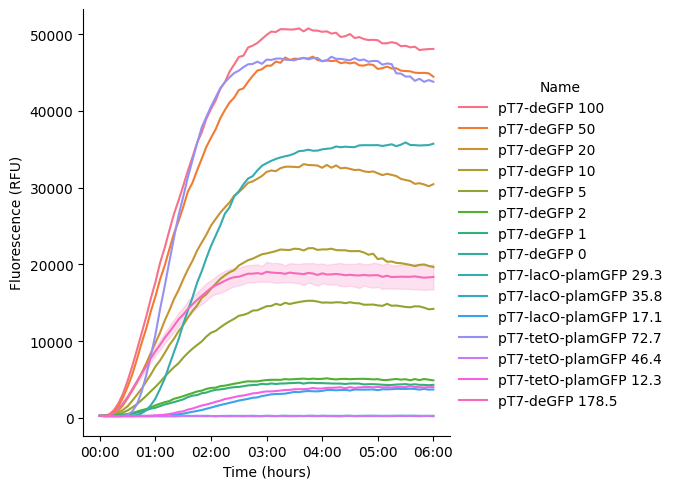

Well,Experiment,Name,DNA Template,[DNA Template] (ng/uL)
B1,Concentration,pT7-deGFP 100,pT7-deGFP (AR-11),100.000000
B2,Concentration,pT7-deGFP 50,pT7-deGFP (AR-11),50.000000
B3,Concentration,pT7-deGFP 20,pT7-deGFP (AR-11),20.000000
B4,Concentration,pT7-deGFP 10,pT7-deGFP (AR-11),10.000000
B5,Concentration,pT7-deGFP 5,pT7-deGFP (AR-11),5.000000
B6,Concentration,pT7-deGFP 2,pT7-deGFP (AR-11),2.000000
B7,Concentration,pT7-deGFP 1,pT7-deGFP (AR-11),1.000000
B8,Concentration,pT7-deGFP 0,pT7-deGFP (AR-11),0.000000
C1,Artifact,pT7-lacO-plamGFP 29.3,pT7-lacO-plamGFP (20240622),29.300000
C2,Artifact,pT7-lacO-plamGFP 35.8,pT7-lacO-plamGFP (20240626),35.800000


In [20]:
g = pr.plot_curves(data)
plt.show()
display(platemap.style.hide(axis="index"))

# Kinetics Impl

## Percent change
Use percent change to determine when steady state variables are no longer changing.

/tmp/ipykernel_2056754/2319108074.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dg = data.groupby(["Well", "Read"]).apply(find_ss)


Well  Read   
B1    490,520   0 days 03:30:00
B2    490,520   0 days 03:35:00
B3    490,520   0 days 03:35:00
B4    490,520   0 days 03:40:00
B5    490,520   0 days 03:25:00
B6    490,520   0 days 03:55:00
B7    490,520   0 days 03:10:00
B8    490,520   0 days 03:15:00
C1    490,520   0 days 04:30:00
C2    490,520   0 days 01:40:00
C3    490,520   0 days 04:30:00
C4    490,520   0 days 03:25:00
C5    490,520   0 days 00:55:00
C6    490,520   0 days 04:25:00
C7    490,520   0 days 02:55:00
C8    490,520   0 days 03:05:00
dtype: timedelta64[ns]


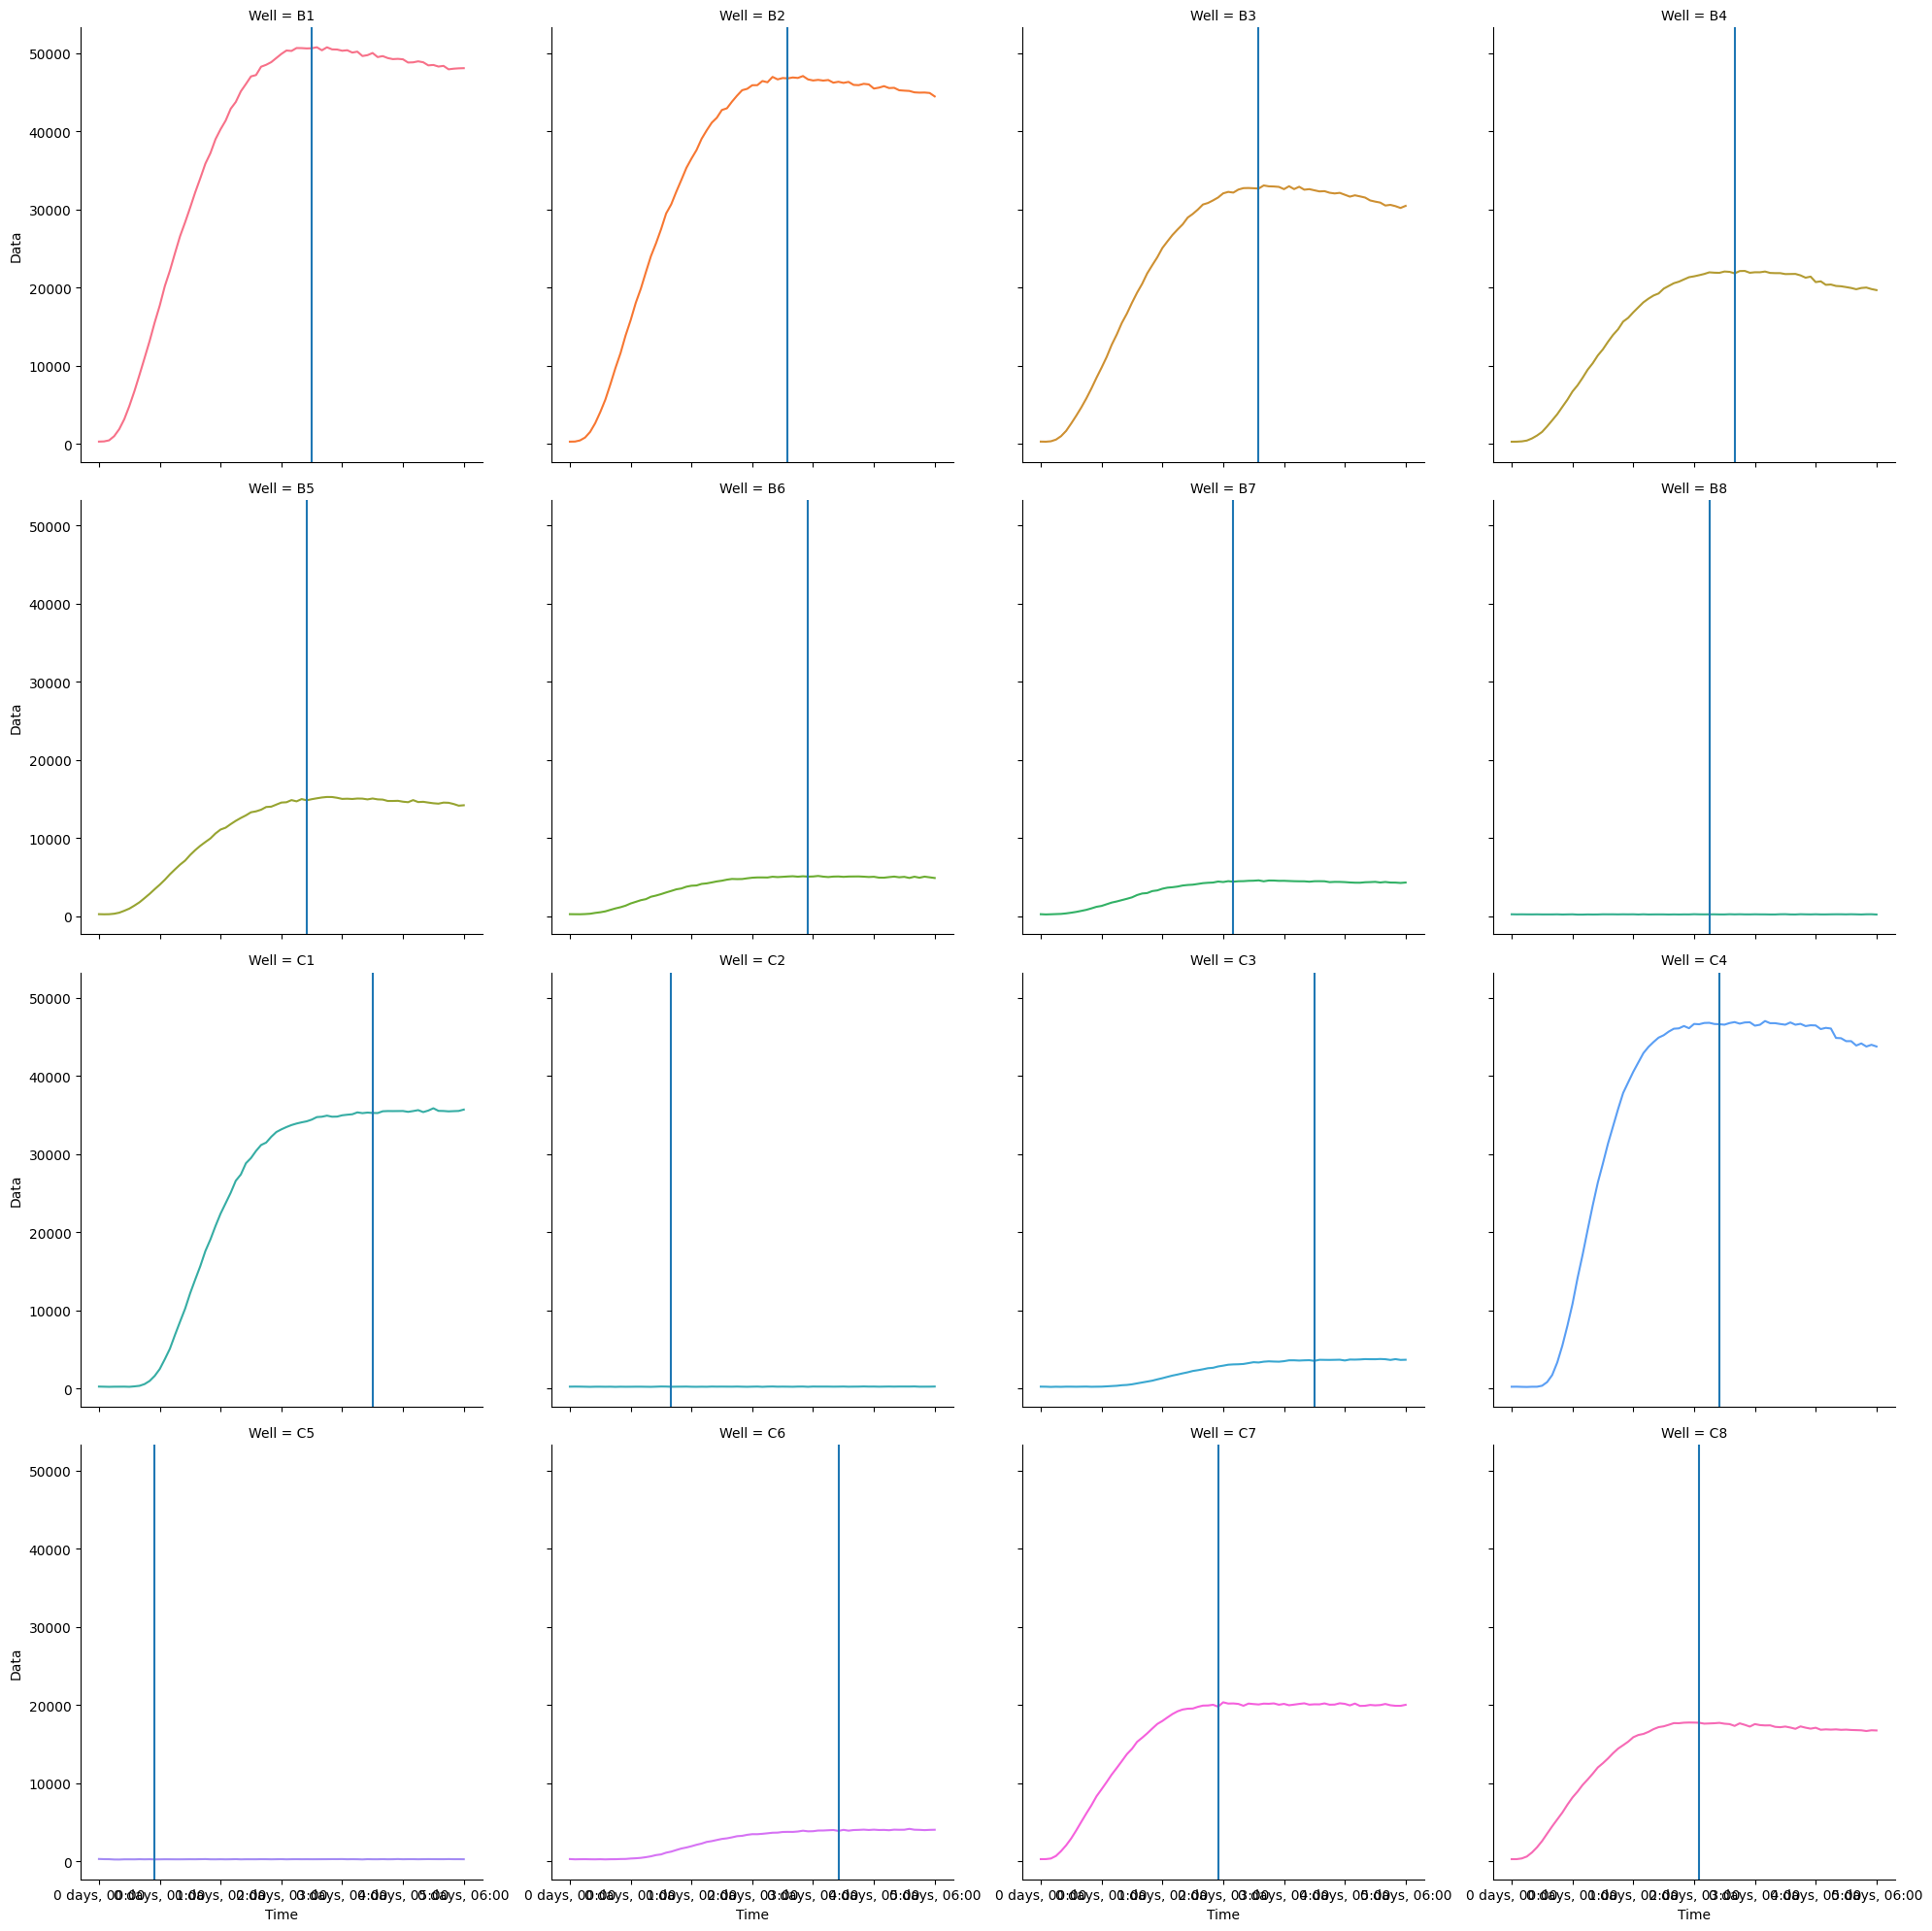

In [ ]:
def find_ss(data):
     pct_change = data.set_index("Time")["Data"].rolling(3).mean().pct_change()
     idx_maxV = pct_change.idxmax()
     return (pct_change[idx_maxV:] < 0).idxmax()

dg = data.groupby(["Well", "Read"]).apply(find_ss)

g = sns.relplot(data, x="Time", y="Data", hue="Well", col="Well", col_wrap=4, kind="line", legend=False)

def vline(data, *args, **kwargs):
     plt.axvline(dg[data["Well"].iloc[0]].iloc[0])
g.map_dataframe(vline)
print(dg)

/tmp/ipykernel_2056754/2356597314.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dg = data.groupby(["Well", "Read"]).apply(find_ss)


Well  Read   
B1    490,520   0 days 03:30:00
B2    490,520   0 days 03:45:00
B3    490,520   0 days 04:25:00
B4    490,520   0 days 05:55:00
B5    490,520   0 days 04:30:00
B6    490,520   0 days 04:10:00
B7    490,520   0 days 03:20:00
B8    490,520   0 days 03:20:00
C1    490,520   0 days 05:10:00
C2    490,520   0 days 05:30:00
C3    490,520   0 days 03:55:00
C4    490,520   0 days 03:55:00
C5    490,520   0 days 01:25:00
C6    490,520   0 days 04:45:00
C7    490,520   0 days 04:25:00
C8    490,520   0 days 05:30:00
dtype: timedelta64[ns]


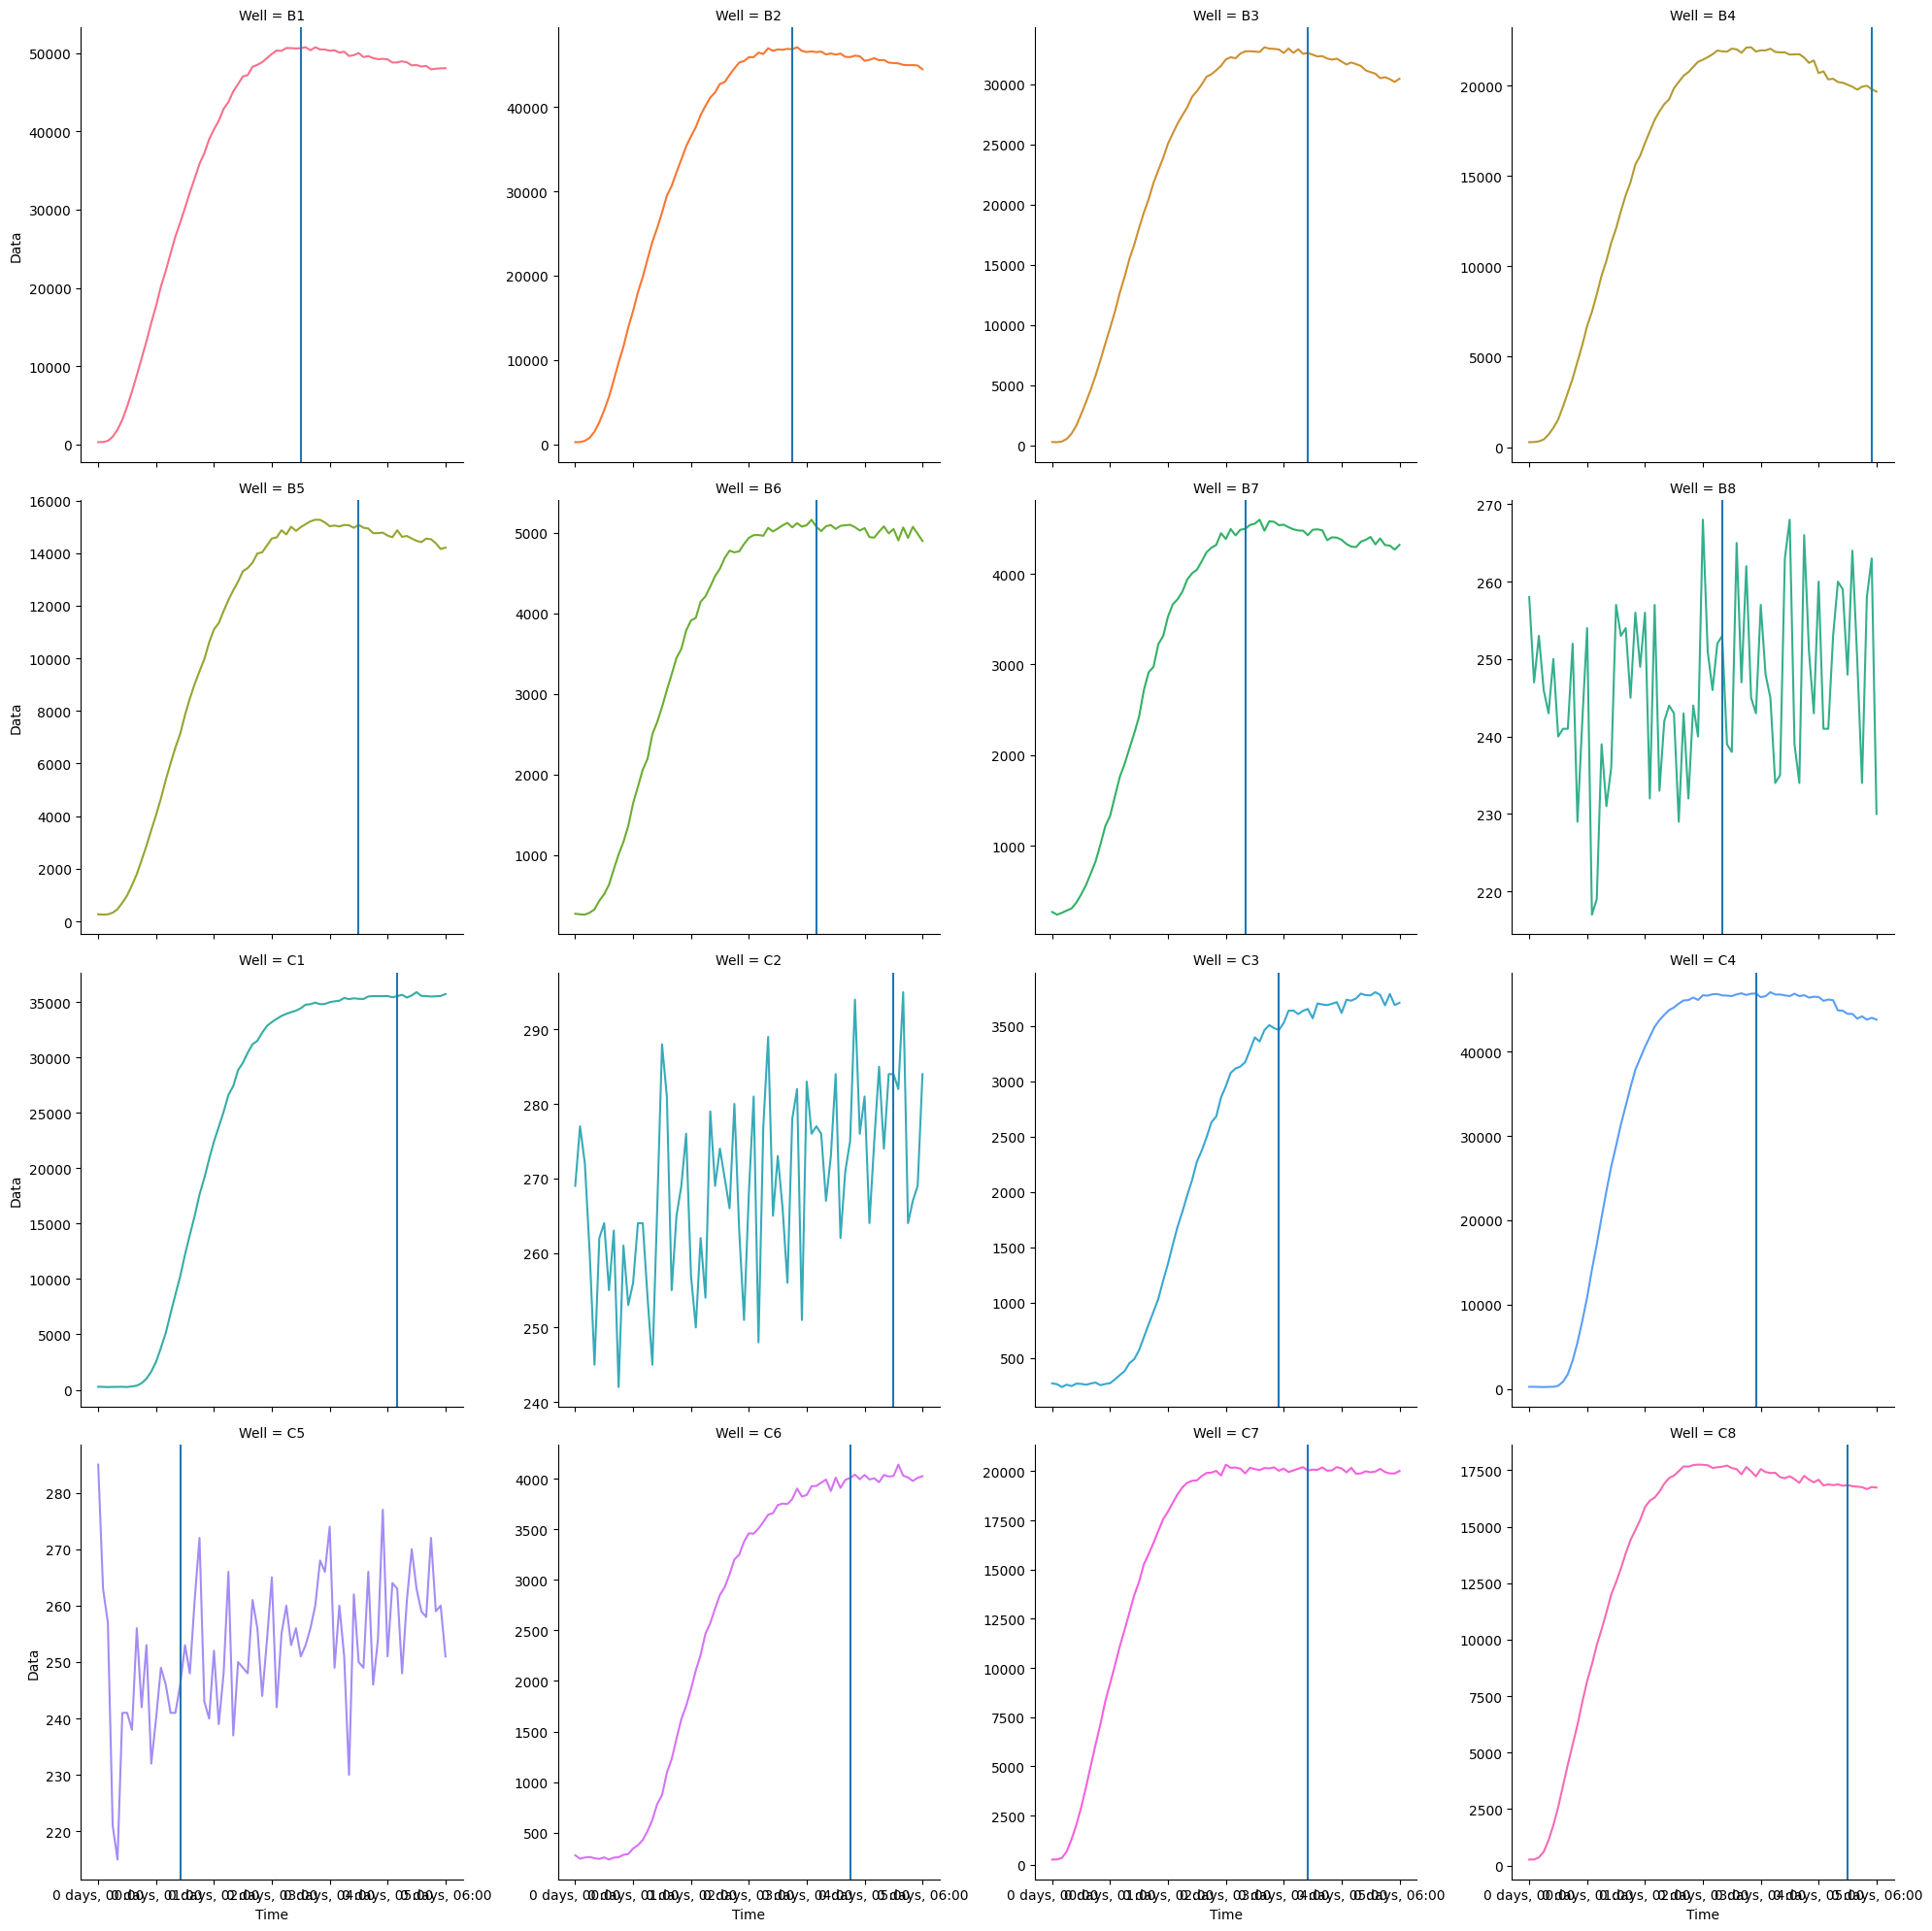

In [ ]:
def find_ss(data):
     pct_change = data.set_index("Time")["Data"].rolling(3).mean().pct_change()
     idx_maxV = pct_change.idxmax()
     return pct_change[idx_maxV:].abs().idxmin()

dg = data.groupby(["Well", "Read"]).apply(find_ss)

g = sns.relplot(data, x="Time", y="Data", hue="Well", col="Well", col_wrap=4, kind="line", legend=False, facet_kws={"sharey": False})

def vline(data, *args, **kwargs):
     plt.axvline(dg[data["Well"].iloc[0]].iloc[0])
g.map_dataframe(vline)
print(dg)

In [ ]:
pr.find_steady_state(data)

,,Time_steadystate,Data_steadystate
Well,Read,,
B1,"490,520",0 days 03:30:00,50621.0
B2,"490,520",0 days 03:45:00,46821.0
B3,"490,520",0 days 04:25:00,32592.0
B4,"490,520",0 days 05:55:00,19808.0
B5,"490,520",0 days 04:30:00,15073.0
B6,"490,520",0 days 04:10:00,5075.0
B7,"490,520",0 days 03:20:00,4498.0
B8,"490,520",0 days 03:20:00,253.0
C1,"490,520",0 days 05:10:00,35535.0


In [ ]:
s = pr.kinetic_analysis_per_well(data[data["Well"] == "B1"])
s

Velocity      Time              0 days 01:05:00
              Data                      20189.0
              Max                      8.283333
Lag           Time    0 days 00:24:22.696177062
Steady State  Time              0 days 03:30:00
              Data                      50621.0
dtype: object

In [ ]:
data.groupby(["Well"]).apply(pr.kinetic_analysis_per_well)

/home/acjs/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:468: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = scipy.optimize.curve_fit(
/home/acjs/code/bnext/cdk/src/cdk/analysis/cytosol/platereader.py:468: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = scipy.optimize.curve_fit(


Failed to solve: Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Failed to solve: Optimal parameters not found: Number of calls to function has reached maxfev = 800.


/tmp/ipykernel_2056754/648837969.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby(["Well"]).apply(pr.kinetic_analysis_per_well)


Velocity                                           Lag  \
                Time     Data        Max                      Time   
Well                                                                 
B1   0 days 01:05:00  20189.0   8.283333 0 days 00:24:22.696177062   
B2   0 days 00:55:00  13878.0   7.556667 0 days 00:24:23.475959418   
B3   0 days 01:10:00  12679.0   5.220000 0 days 00:29:31.072796935   
B4   0 days 01:00:00   6700.0   3.500000 0 days 00:28:05.714285714   
B5   0 days 01:30:00   7850.0   2.403333 0 days 00:35:33.703190014   
B6   0 days 01:20:00   2502.0   1.016667 0 days 00:38:59.016393443   
B7   0 days 01:35:00   2718.0   0.980000 0 days 00:48:46.530612245   
B8   0 days 03:00:00    268.0   0.093333 0 days 02:12:08.571428571   
C1   0 days 01:30:00  12223.0   6.603333 0 days 00:59:08.965169107   
C2               NaT      NaN        NaN                       NaT   
C3   0 days 02:05:00   1524.0   0.573333 0 days 01:20:41.860465116   
C4   0 days 01:05:00  14167.0  11.056667 0 days 00:43:38.691588785   
C5               NaT      NaN        NaN                       NaT   
C6   0 days 01:35:00   1093.0   0.740000 0 days 01:10:22.972972973   
C7   0 days 00:55:00   8308.0   3.836667 0 days 00:18:54.578627281   
C8   0 days 00:55:00   7234.0   3.366667 0 days 00:19:11.287128713   

        Steady State           
                Time     Data  
Well                           
B1   0 days 03:30:00  50621.0  
B2   0 days 03:45:00  46821.0  
B3   0 days 04:25:00  32592.0  
B4   0 days 05:55:00  19808.0  
B5   0 days 04:30:00  15073.0  
B6   0 days 04:10:00   5075.0  
B7   0 days 03:20:00   4498.0  
B8   0 days 03:20:00    253.0  
C1   0 days 05:10:00  35535.0  
C2               NaT      NaN  
C3   0 days 03:55:00   3464.0  
C4   0 days 03:55:00  46897.0  
C5               NaT      NaN  
C6   0 days 04:45:00   4008.0  
C7   0 days 04:25:00  20034.0  
C8   0 days 05:30:00  16839.0

In [5]:
kinetics = pr.kinetic_analysis(data)
kinetics

Failed to solve: Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Failed to solve: Optimal parameters not found: Number of calls to function has reached maxfev = 800.


Velocity                                           Lag  \
                        Time     Data        Max                      Time   
Well Read                                                                    
B1   490,520 0 days 01:05:00  20189.0   8.283333 0 days 00:24:22.696177062   
B2   490,520 0 days 00:55:00  13878.0   7.556667 0 days 00:24:23.475959418   
B3   490,520 0 days 01:10:00  12679.0   5.220000 0 days 00:29:31.072796935   
B4   490,520 0 days 01:00:00   6700.0   3.500000 0 days 00:28:05.714285714   
B5   490,520 0 days 01:30:00   7850.0   2.403333 0 days 00:35:33.703190014   
B6   490,520 0 days 01:20:00   2502.0   1.016667 0 days 00:38:59.016393443   
B7   490,520 0 days 01:35:00   2718.0   0.980000 0 days 00:48:46.530612245   
B8   490,520 0 days 03:00:00    268.0   0.093333 0 days 02:12:08.571428571   
C1   490,520 0 days 01:30:00  12223.0   6.603333 0 days 00:59:08.965169107   
C2   490,520             NaT      NaN        NaN                       NaT   
C3   490,520 0 days 02:05:00   1524.0   0.573333 0 days 01:20:41.860465116   
C4   490,520 0 days 01:05:00  14167.0  11.056667 0 days 00:43:38.691588785   
C5   490,520             NaT      NaN        NaN                       NaT   
C6   490,520 0 days 01:35:00   1093.0   0.740000 0 days 01:10:22.972972973   
C7   490,520 0 days 00:55:00   8308.0   3.836667 0 days 00:18:54.578627281   
C8   490,520 0 days 00:55:00   7234.0   3.366667 0 days 00:19:11.287128713   

                             Steady State                    Fit            \
                     Data            Time     Data             L         k   
Well Read                                                                    
B1   490,520  5339.741412 0 days 03:30:00  50621.0  50290.118584  0.000642   
B2   490,520  4818.951864 0 days 03:45:00  46821.0  46486.667493  0.000631   
B3   490,520  3579.016572 0 days 04:25:00  32592.0  32753.456656  0.000619   
B4   490,520  2071.910207 0 days 05:55:00  19808.0  21291.854364  0.000674   
B5   490,520  1864.947701 0 days 04:30:00  15073.0  15073.093042  0.000597   
B6   490,520   872.683716 0 days 04:10:00   5075.0   5093.574709  0.000579   
B7   490,520     0.000000 0 days 03:20:00   4498.0      0.000000  0.000000   
B8   490,520     0.000000 0 days 03:20:00    253.0      0.000000  0.000000   
C1   490,520  3770.868088 0 days 05:10:00  35535.0  35013.270550  0.000729   
C2   490,520          NaN             NaT      NaN           NaN       NaN   
C3   490,520   523.349603 0 days 03:55:00   3464.0   3673.268780  0.000533   
C4   490,520  4762.911848 0 days 03:55:00  46897.0  46427.486081  0.000949   
C5   490,520          NaN             NaT      NaN           NaN       NaN   
C6   490,520   562.431551 0 days 04:45:00   4008.0   3949.340340  0.000569   
C7   490,520  2148.565456 0 days 04:25:00  20034.0  20073.070854  0.000737   
C8   490,520  1848.803346 0 days 05:30:00  16839.0  17333.188902  0.000759   

                           
                       x0  
Well Read                  
B1   490,520  4778.934007  
B2   490,520  4884.370079  
B3   490,520  5162.189926  
B4   490,520  4989.961442  
B5   490,520  5411.880644  
B6   490,520  5063.401885  
B7   490,520     0.000000  
B8   490,520     0.000000  
C1   490,520  6447.697283  
C2   490,520          NaN  
C3   490,520  8207.272502  
C4   490,520  4904.727521  
C5   490,520          NaN  
C6   490,520  7376.260417  
C7   490,520  4012.837260  
C8   490,520  3952.780267

In [28]:
import numpy as np

In [ ]:
m = data["Time"].max()
m.nanoseconds

Timedelta('0 days 06:00:00')

In [48]:
np.linspace(data["Time"].min().nanoseconds, data["Time"].max().nanoseconds, 100)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
import timple

In [18]:
import timple.timedelta


timple.timedelta.timedelta2num(d["Time"].max())

np.float64(0.25)

In [47]:
ax.get_xlim()

(np.float64(-0.0125), np.float64(0.2625))

In [55]:
kinetics["Velocity", "Max"]

Well  Read   
B1    490,520     8.283333
B2    490,520     7.556667
B3    490,520     5.220000
B4    490,520     3.500000
B5    490,520     2.403333
B6    490,520     1.016667
B7    490,520     0.980000
B8    490,520     0.093333
C1    490,520     6.603333
C2    490,520          NaN
C3    490,520     0.573333
C4    490,520    11.056667
C5    490,520          NaN
C6    490,520     0.740000
C7    490,520     3.836667
C8    490,520     3.366667
Name: (Velocity, Max), dtype: float64

In [93]:
k["Velocity", "Time"].total_seconds()

3900.0

In [83]:
d["Time"].loc[(maxV_y > 0) & (maxV_y < d["Data"].max())]

1    0 days 00:05:00
2    0 days 00:10:00
3    0 days 00:15:00
4    0 days 00:20:00
5    0 days 00:25:00
6    0 days 00:30:00
7    0 days 00:35:00
8    0 days 00:40:00
9    0 days 00:45:00
10   0 days 00:50:00
11   0 days 00:55:00
12   0 days 01:00:00
13   0 days 01:05:00
14   0 days 01:10:00
15   0 days 01:15:00
16   0 days 01:20:00
17   0 days 01:25:00
18   0 days 01:30:00
19   0 days 01:35:00
20   0 days 01:40:00
21   0 days 01:45:00
Name: Time, dtype: timedelta64[ns]

/tmp/ipykernel_2420355/1238535407.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v["Velocity"] = maxV_y


<Axes: xlabel='Time', ylabel='Data'>

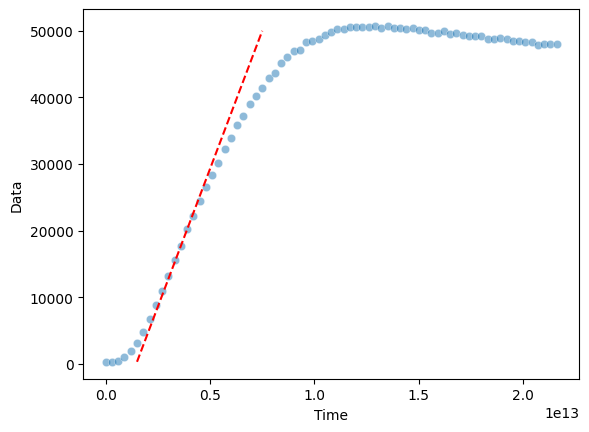

In [10]:
d = data[data["Well"] == "B1"]
k = kinetics.loc["B1", "490,520"]
ax = sns.scatterplot(data=d, x="Time", y="Data", alpha=0.5)
# maxV_x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
maxV_x = pd.timedelta_range(start=d["Time"].min(), end=d["Time"].max(), periods=100)
maxV_y = (
    k["Velocity", "Max"] * ((d["Time"] - k["Velocity", "Time"]).dt.total_seconds()) + k["Velocity", "Data"]
)

v = d.loc[(maxV_y > 0) & (maxV_y < d["Data"].max())]
v["Velocity"] = maxV_y

sns.lineplot(
    data=v,
    x="Time",
    y="Velocity",
    linestyle="--",
    c="r",
    ax=ax,
)


In [19]:
f = timple.timedelta.TimedeltaFormatter("%h:%m")
f.format_data(timple.timedelta.timedelta2num(k["Lag", "Time"]))

'00:24'

Velocity      Time              0 days 01:05:00
              Data                      20189.0
              Max                      8.283333
Lag           Time    0 days 00:24:22.696177062
              Data                  5339.741412
Steady State  Time              0 days 03:30:00
              Data                      50621.0
Fit           L                    50290.118584
              k                        0.000642
              x0                    4778.934007
Name: (B1, 490,520), dtype: object
0 days 03:30:00


/home/acjs/code/bnext/cdk/.venv/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)


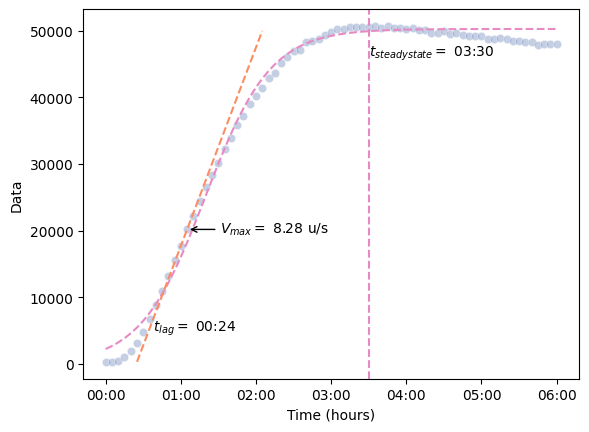

In [24]:
pr.plot_kinetics_by_well(d, kinetics, show_fit=True, annotate=True)

/home/acjs/code/bnext/cdk/.venv/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/acjs/code/bnext/cdk/.venv/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/acjs/code/bnext/cdk/.venv/lib/python3.11/site-packages/seaborn/relational.py:438

0 days 03:30:00
0 days 03:45:00
0 days 04:25:00
0 days 05:55:00
0 days 04:30:00
0 days 04:10:00
0 days 03:20:00
0 days 03:20:00
0 days 05:10:00
0 days 03:55:00
0 days 03:55:00


/home/acjs/code/bnext/cdk/.venv/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/acjs/code/bnext/cdk/.venv/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)
/home/acjs/code/bnext/cdk/.venv/lib/python3.11/site-packages/seaborn/relational.py:438

0 days 04:45:00
0 days 04:25:00
0 days 05:30:00


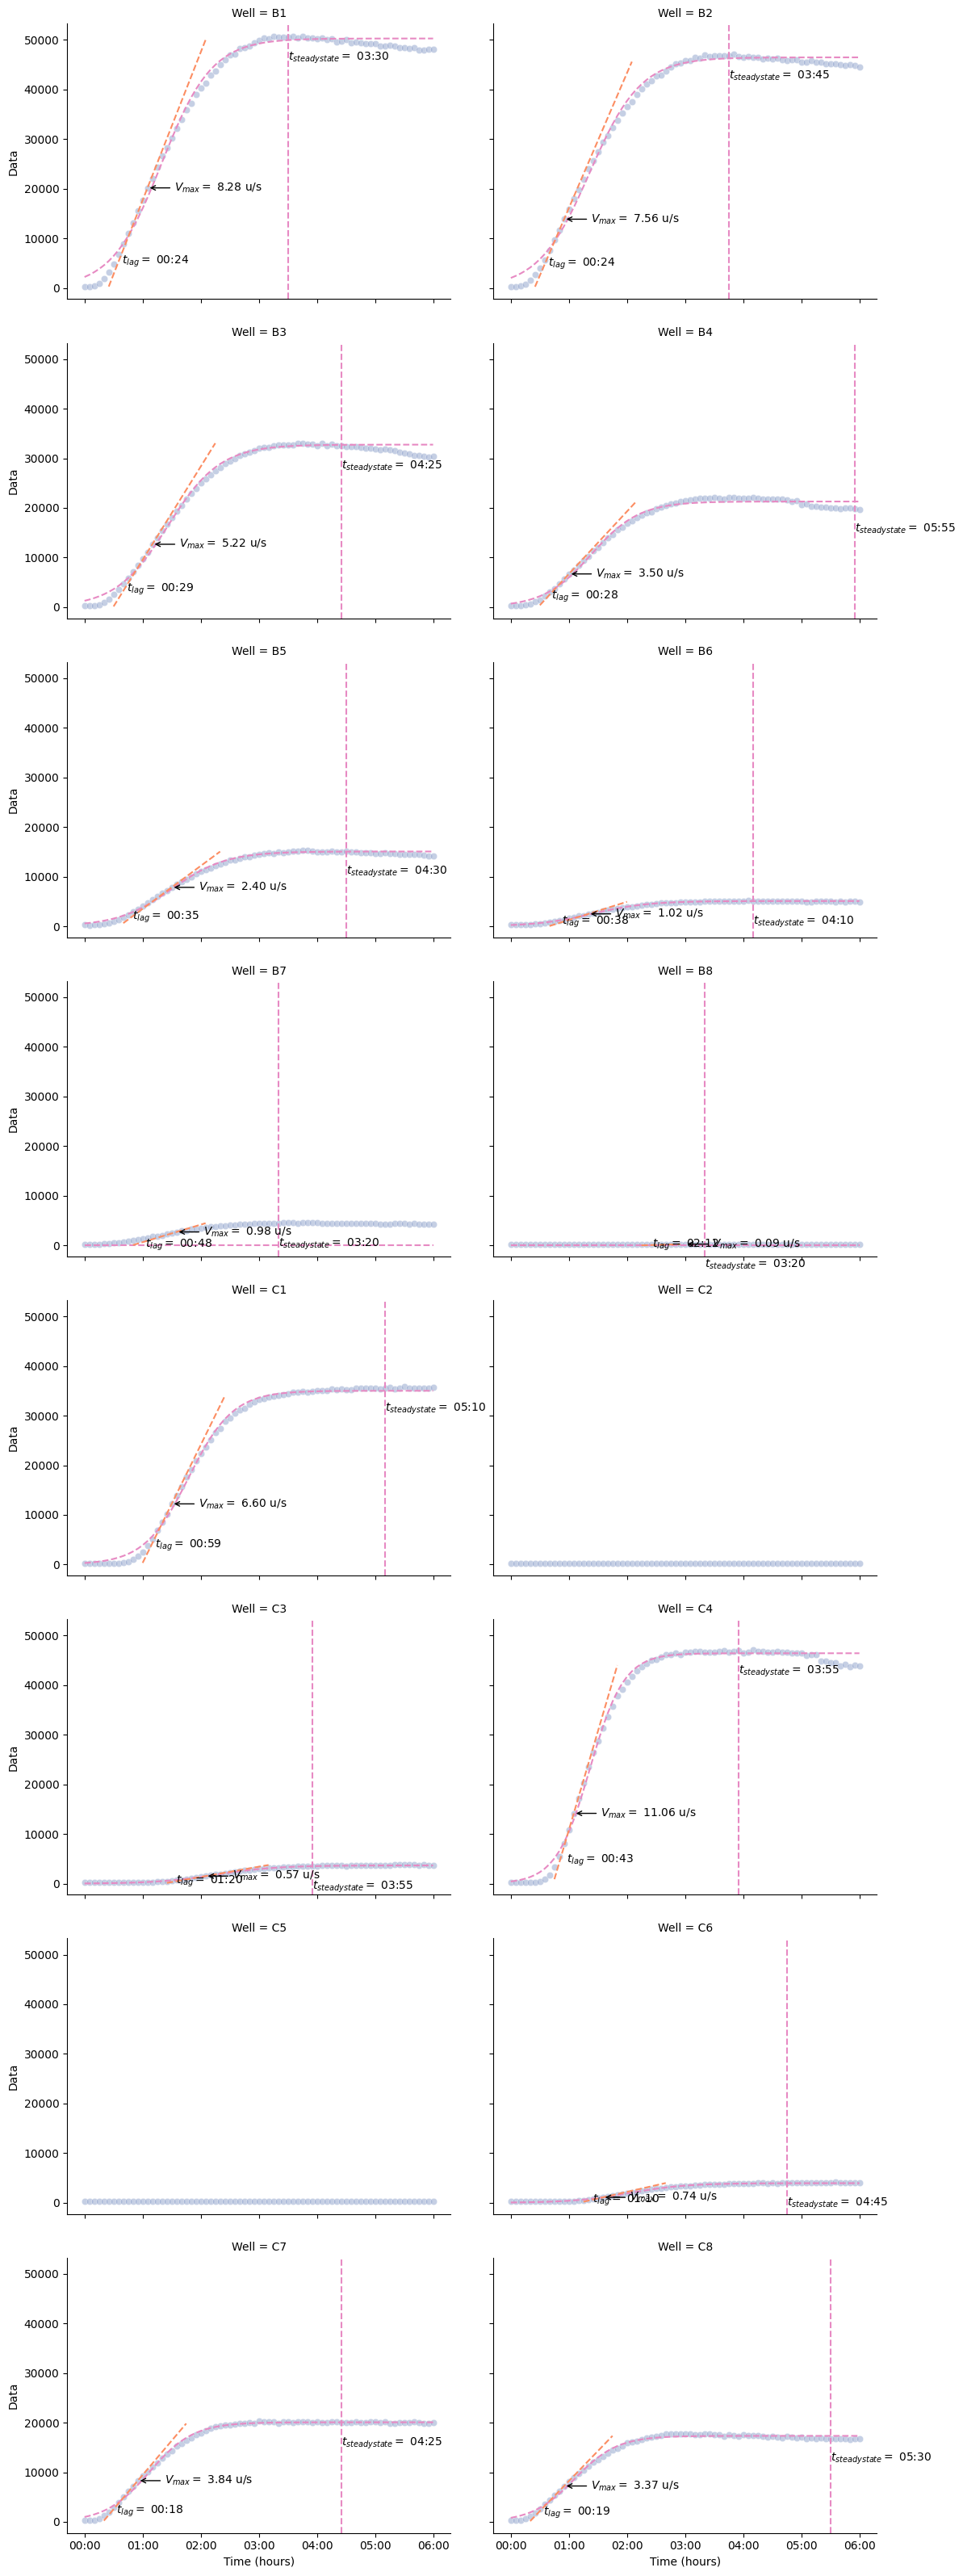

In [27]:
pr.plot_kinetics(data, kinetics)

/tmp/ipykernel_3010507/2370316043.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dg = data.groupby(["Well", "Read"]).apply(


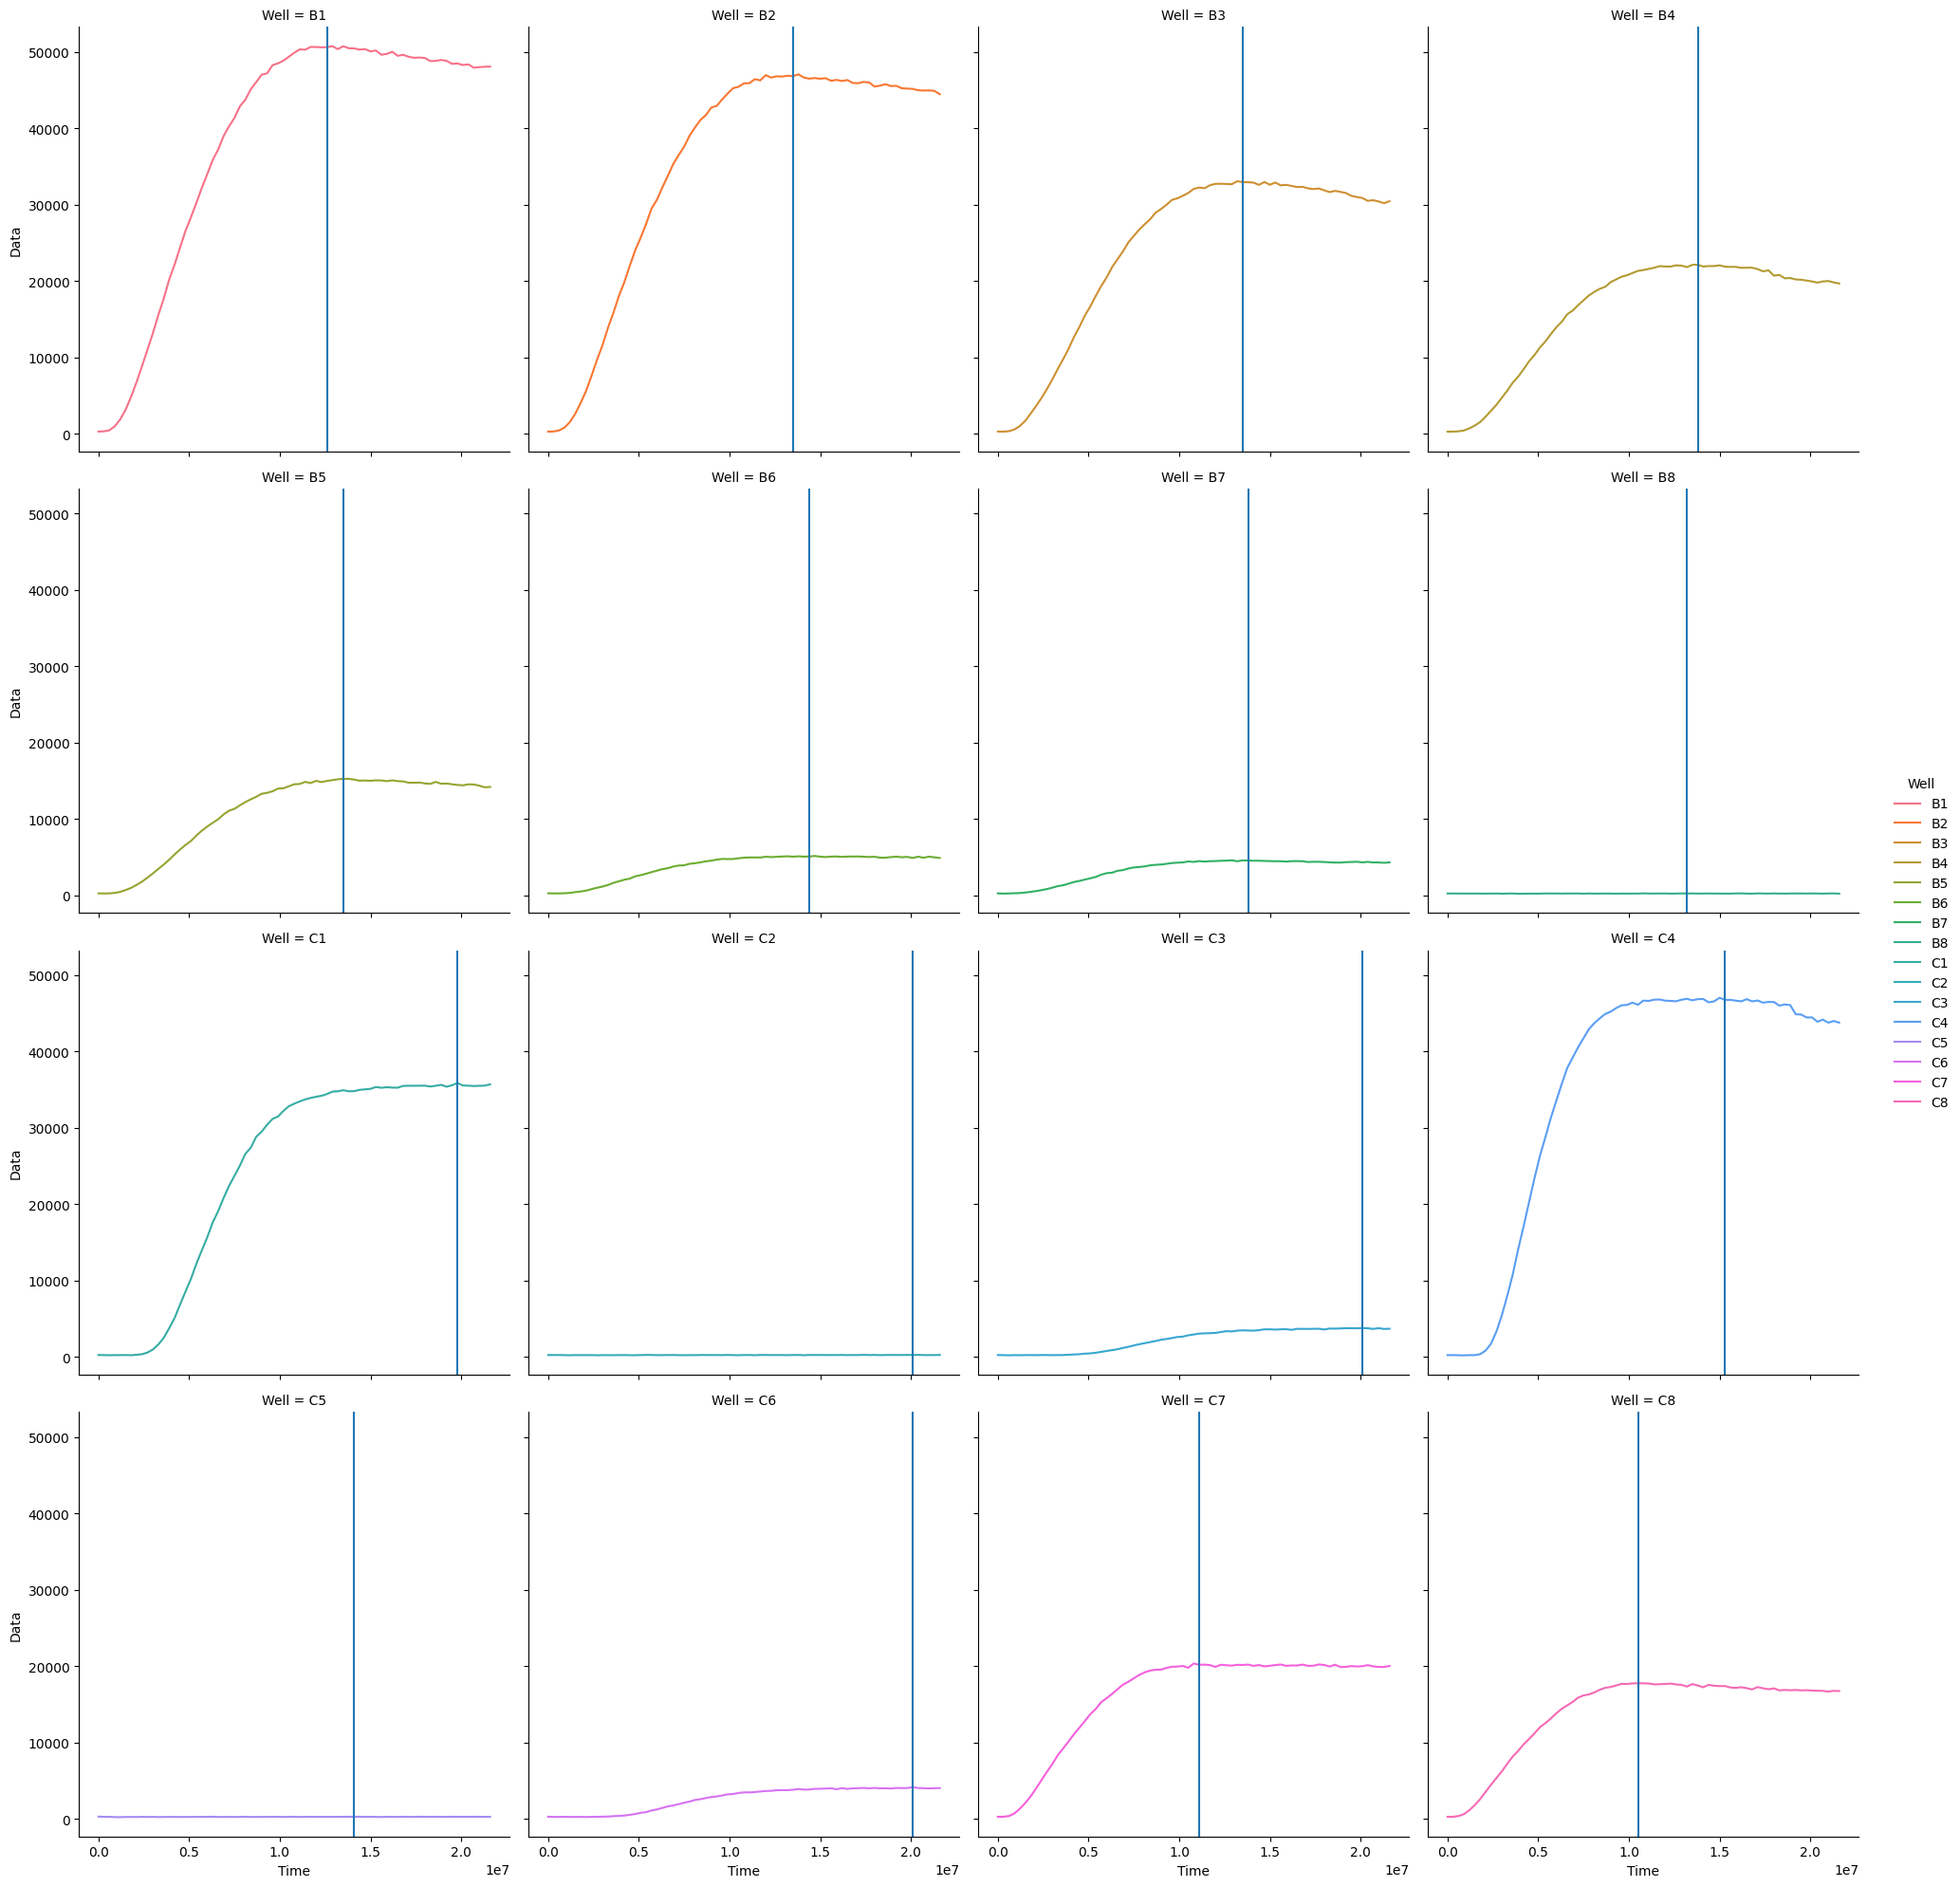

In [ ]:
dg = data.groupby(["Well", "Read"]).apply(
    lambda x: x.set_index("Time")["Data"].rolling(3, center=True).mean()
)
dg = dg.melt(ignore_index=False).reset_index()

g = sns.relplot(data=data, x="Time", y="Data", hue="Well", col="Well", col_wrap=4, kind="line")

def vline(data, *args, **kwargs):
    plt.axvline(data["Time"].loc[data["Data"].rolling(3, center=True).mean().idxmax()].to_timedelta64().astype("float64"))
g.map_dataframe(vline)

# g.map_dataframe(lambda x: plt.axvline(x["Time"].iloc[x["Data"].idxmax()]))
# for i in range(2):
#     ax[i].axvline(dg.groupby("Time")["value"].mean().idxmax().to_timedelta64().astype("float64"))
# sns.relplot(data=dg)

In [ ]:
a.get_xlim()

(np.float64(-1080000.0), np.float64(22680000.0))

In [ ]:
t = (dg.groupby("Time")["value"].mean()).idxmax()
t.to_timedelta64().astype("float64")

np.float64(13800000.0)

# Features

## v0.2.0
- plot_overview()
- plot_steadystate()
- plot_kinetics()
- plot_heatmap()
- plot_slice()
- plot_explore()---widget data exploration
- kinetics()---kinetics table
- blanking()

## v0.2.1
- save images
- code version / reproducibility information---version()
- final output---contains everything you might want
- convert into units of molarity using standard curve

In [ ]:
import cdk

In [ ]:
from importlib.metadata import version
version('cdk')

'0.1.0'